# YB 2조 mini project (2) 와인 품질 분류 예측 경진대회 분류 알고리즘
- 관련 사이트 : https://dacon.io/competitions/open/235610/overview/description
- 과제 : 데이콘의 '와인 품질 분류 예측 경진대회' 데이터셋을 전처리 및 시각화하고, 분류 알고리즘 적용하기
- 조건 : 분류 모델 3가지 이상 적용
- 분석 파일을 1) 제출 후 리더보드에서 점수 확인 2) github에 업로드하여 점수와 깃허브 링크를 과제함에 댓글로 달아주시면 됩니다.
- 리더보드 점수 고득점팀 1위 조원분들께는 우수학회원 점수 가산이 있을 예정입니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

test_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test.csv")
train_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine_train.csv")
submission_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine_sample_submission.csv")

Mounted at /content/drive


In [ ]:
test_data.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


In [ ]:
train_data.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


In [ ]:
submission_data.head()

,index,quality
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


##1. 데이터 기초 정제 및 범주형 EDA

<br>

###1. 데이터 기초 정제

In [ ]:
# 결측치 및 중복값 확인
print("--- train_data 결측치 확인 ---")
display(train_data.isnull().sum())

print("\n--- train_data 중복값 확인 ---")
print(f"중복된 행 수: {train_data.duplicated().sum()}")

print("\n--- test_data 결측치 확인 ---")
display(test_data.isnull().sum())

print("\n--- test_data 중복값 확인 ---")
print(f"중복된 행 수: {test_data.duplicated().sum()}")

--- train_data 결측치 확인 ---


,0
index,0
quality,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0



--- train_data 중복값 확인 ---
중복된 행 수: 0

--- test_data 결측치 확인 ---


,0
index,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0



--- test_data 중복값 확인 ---
중복된 행 수: 0



> train_data와 test_data 모두 결측값 및 중복된 행이 존재하지 않는다. 데이터는 깨끗한 상태라고 할 수 있다.


In [ ]:
# 'type'(범주형) 변수 One-Hot 인코딩
# white 와인일 경우 1, red 와인일 경우 0을 가진다.
train_data_encoded = pd.get_dummies(train_data, columns=['type'], drop_first=True)
test_data_encoded = pd.get_dummies(test_data, columns=['type'], drop_first=True)

print("--- 인코딩 후 train_data의 'type' 열 확인 ---")
display(train_data_encoded[['type_white']].astype(int).head())

print("--- 인코딩 후 test_data의 'type' 열 확인 ---")
display(test_data_encoded[['type_white']].astype(int).head())

--- 인코딩 후 train_data의 'type' 열 확인 ---


,type_white
0,1
1,0
2,1
3,1
4,1


--- 인코딩 후 test_data의 'type' 열 확인 ---


,type_white
0,1
1,0
2,1
3,1
4,1



###2. 범주형 EDA

In [ ]:
# type 변수 분석
print("--- Train Data 'type' 변수 빈도 ---")
display(train_data['type'].value_counts())

print("\n--- Train Data 'type' 변수 비율 ---")
display(train_data['type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- Test Data 'type' 변수 빈도 ---")
display(test_data['type'].value_counts())

print("\n--- Test Data 'type' 변수 비율 ---")
display(test_data['type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Train Data 'type' 변수 빈도 ---


,count
type,
white,4159
red,1338



--- Train Data 'type' 변수 비율 ---


,proportion
type,
white,75.66%
red,24.34%



--- Test Data 'type' 변수 빈도 ---


,count
type,
white,739
red,261



--- Test Data 'type' 변수 비율 ---


,proportion
type,
white,73.9%
red,26.1%


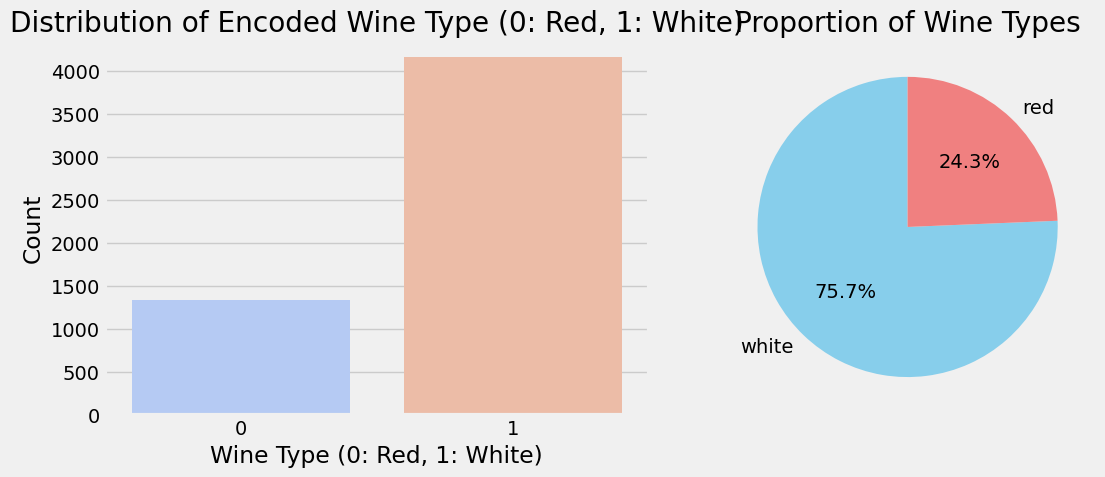

In [ ]:
# type 변수 분포 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Countplot for Wine Type
sns.countplot(data=train_data_encoded, x=train_data_encoded["type_white"].astype(int), palette="coolwarm", ax=ax[0])
ax[0].set_title("Distribution of Encoded Wine Type (0: Red, 1: White)")
ax[0].set_xlabel("Wine Type (0: Red, 1: White)")
ax[0].set_ylabel("Count")

# Subplot 2: Pie Chart for Wine Type
wine_type_counts = train_data['type'].value_counts()
ax[1].pie(
    wine_type_counts,
    labels=wine_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightcoral']
)
ax[1].set_title("Proportion of Wine Types")
ax[1].set_ylabel('') # Hide the default 'y' label for pie chart

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()



> 대부분의 와인이 'White Wine' (1)이며, 'Red Wine' (0)은 상대적으로 적은 비중을 차지하고 있음을 보여준다.

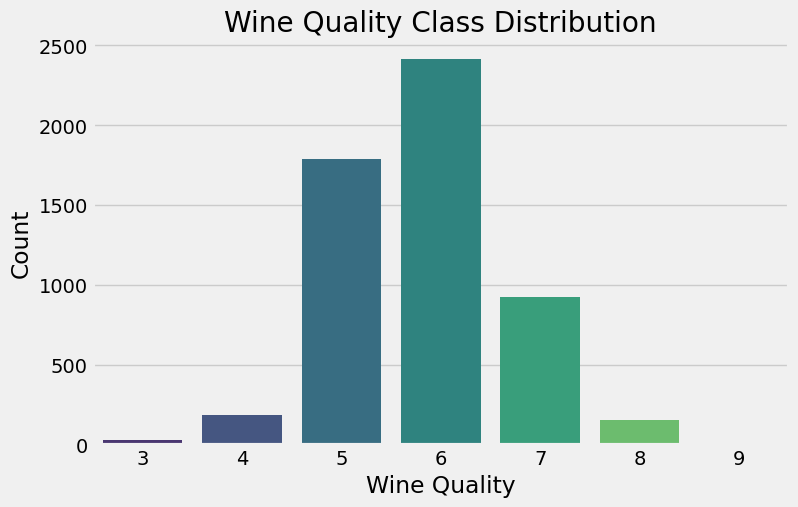

--- Quality 클래스별 데이터 개수 ---


,count
quality,
3,26
4,186
5,1788
6,2416
7,924
8,152
9,5


In [ ]:
# quality 분포 그래프로 확인 (Countplot)
plt.figure(figsize=(8,5))
sns.countplot(
    data=train_data,
    x="quality",
    order=sorted(train_data["quality"].unique()),
    palette='viridis'
)
plt.title("Wine Quality Class Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()

# quality 클래스별 데이터 개수
print("--- Quality 클래스별 데이터 개수 ---")
quality_counts = train_data["quality"].value_counts().sort_index()
display(quality_counts)

In [ ]:
# quality 클래스별 데이터 비율 계산
quality_percentages = train_data['quality'].value_counts(normalize=True).sort_index() * 100

print("\n--- Quality 클래스별 데이터 비율 ---")
display(quality_percentages.round(2).astype(str) + '%')


--- Quality 클래스별 데이터 비율 ---


,proportion
quality,
3,0.47%
4,3.38%
5,32.53%
6,43.95%
7,16.81%
8,2.77%
9,0.09%



> 와인 품질(quality) 데이터는 특정 점수대에 집중되어 있다. 특히 '5'점과 '5'점 와인의 비중이 가장 높으며, 그 외 비중은 상대적으로 적다. 즉, 데이터 불균형이 발생함을 확인할 수 있다.

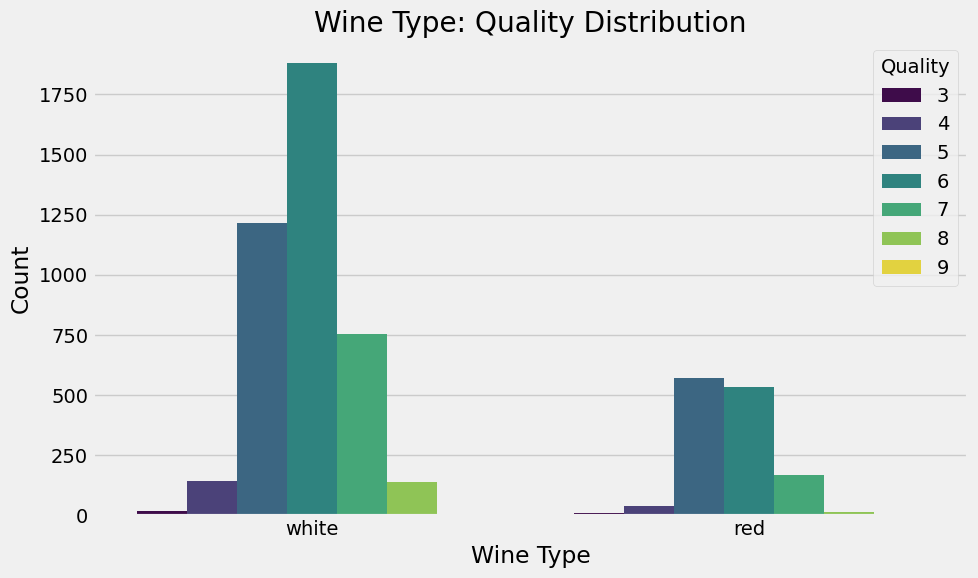


--- 'type' 별 'quality' 분포 (교차표) ---


quality,3,4,5,6,7,8,9
type,,,,,,,
red,9,41,571,535,169,13,0
white,17,145,1217,1881,755,139,5


In [ ]:
# type 변수와 quality 변수의 관계
plt.figure(figsize=(10, 6))
sns.countplot(x='type', hue='quality', data=train_data, palette='viridis')
plt.title('Wine Type: Quality Distribution')
plt.xlabel('Wine Type')
plt.ylabel('Count')
plt.legend(title='Quality')
plt.tight_layout()
plt.show()

print("\n--- 'type' 별 'quality' 분포 (교차표) ---")
display(pd.crosstab(train_data['type'], train_data['quality']))



> quality 분포를 type별로 나눈 그래프를 통해, 전반적으로 화이트 와인이 레드 와인보다 다양한 품질 점수대에 걸쳐 더 많은 개수를 가지고 있음을 확인할 수 있다.

> 종합적으로, 데이터셋은 화이트 와인이 훨씬 많고, 와인 타입에 따라 품질 점수의 분포 패턴이 다소 차이가 있음을 알 수 있다. 특히 quality 변수 자체의 불균형이 두 타입 모두에서 관찰된다.

##2. 수치형 변수 분석 및 스케일링
- 통계적 특성 및 관계를 파악하기


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train = train_data
print("데이터 크기:", train.shape)
print(train.head())
# 수치형 컬럼 전체 선택
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# index는 식별자, quality는 타깃 변수이므로 분포 분석 대상에서는 제외
exclude_cols = ["index", "quality"]
feature_cols = [col for col in numeric_cols if col not in exclude_cols]
print("분석할 수치형 변수:")
print(feature_cols)
summary = train[feature_cols].describe().T
# 중앙값, 왜도, 첨도 추가
summary["median"] = train[feature_cols].median()
summary["skewness"] = train[feature_cols].skew()
summary["kurtosis"] = train[feature_cols].kurtosis()
summary = summary[[
    "count", "mean", "std", "min", "25%", "median", "50%", "75%", "max",
    "skewness", "kurtosis"
]]

summary

데이터 크기: (5497, 14)
   index  quality  fixed acidity  volatile acidity  citric acid  \
0      0        5            5.6             0.695         0.06   
1      1        5            8.8             0.610         0.14   
2      2        5            7.9             0.210         0.39   
3      3        6            7.0             0.210         0.31   
4      4        6            7.8             0.400         0.26   

   residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0             6.8      0.042                  9.0                  84.0   
1             2.4      0.067                 10.0                  42.0   
2             2.0      0.057                 21.0                 138.0   
3             6.0      0.046                 29.0                 108.0   
4             9.5      0.059                 32.0                 178.0   

   density    pH  sulphates  alcohol   type  
0  0.99432  3.44       0.44     10.2  white  
1  0.99690  3.19       0.59      9.

,count,mean,std,min,25%,median,50%,75%,max,skewness,kurtosis
fixed acidity,5497.0,7.210115,1.287579,3.80000,6.4000,7.0000,7.0000,7.70000,15.90000,1.710897,5.135821
volatile acidity,5497.0,0.338163,0.163224,0.08000,0.2300,0.2900,0.2900,0.40000,1.58000,1.497844,2.904959
citric acid,5497.0,0.318543,0.145104,0.00000,0.2500,0.3100,0.3100,0.39000,1.66000,0.492486,2.727035
residual sugar,5497.0,5.438075,4.756676,0.60000,1.8000,3.0000,3.0000,8.10000,65.80000,1.498954,5.157637
chlorides,5497.0,0.055808,0.034653,0.00900,0.0380,0.0470,0.0470,0.06400,0.61000,5.187327,45.986221
free sulfur dioxide,5497.0,30.417682,17.673881,1.00000,17.0000,29.0000,29.0000,41.00000,289.00000,1.310631,9.400331
total sulfur dioxide,5497.0,115.566491,56.288223,6.00000,78.0000,118.0000,118.0000,155.00000,440.00000,0.002601,-0.327730
density,5497.0,0.994673,0.003014,0.98711,0.9923,0.9948,0.9948,0.99693,1.03898,0.604119,7.806521
pH,5497.0,3.219502,0.160713,2.74000,3.1100,3.2100,3.2100,3.32000,4.01000,0.387856,0.384580
sulphates,5497.0,0.530524,0.149396,0.22000,0.4300,0.5100,0.5100,0.60000,2.00000,1.915479,9.743482


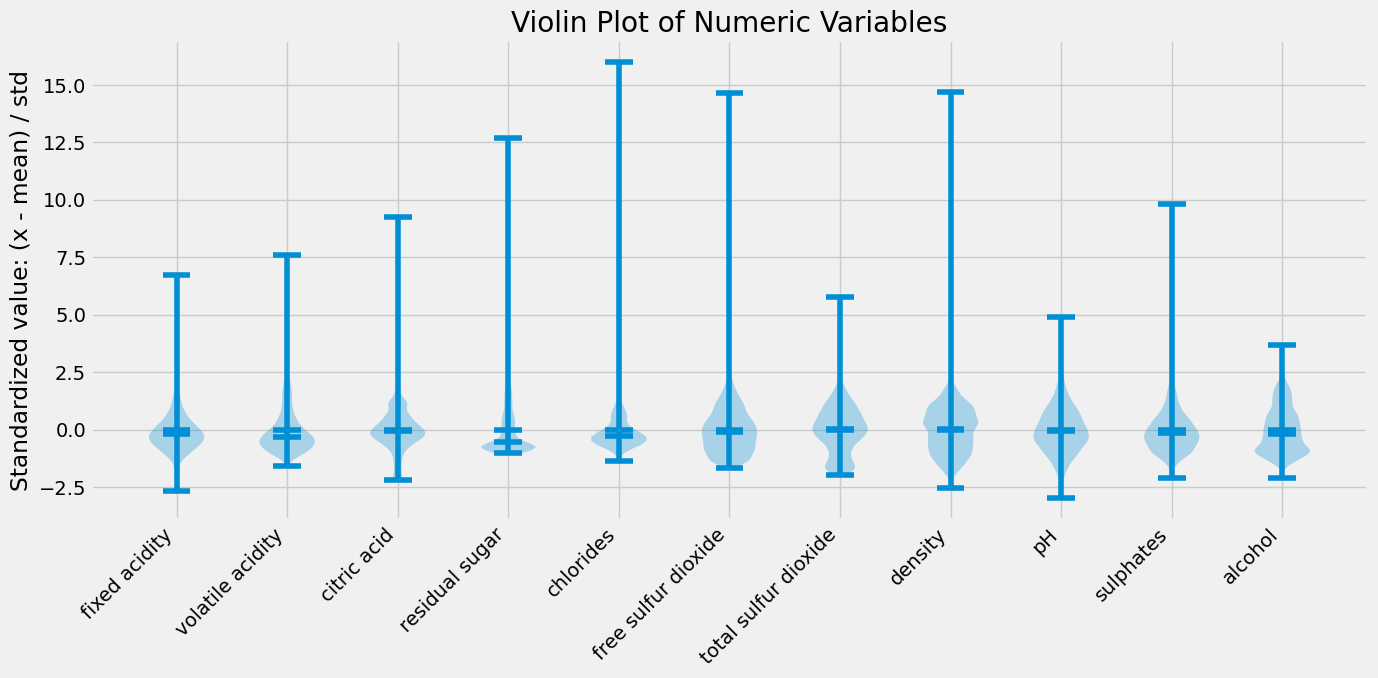

In [ ]:
#바이올린 플롯을 이용한 시각화
scaled_for_plot = (train[feature_cols] - train[feature_cols].mean()) / train[feature_cols].std(ddof=0)

plt.figure(figsize=(14, 7))

plt.violinplot([scaled_for_plot[col].dropna().values for col in feature_cols],
    showmeans=True,
    showmedians=True,
    showextrema=True)

plt.xticks(
    ticks=range(1, len(feature_cols) + 1),
    labels=feature_cols,
    rotation=45,
    ha="right")

plt.ylabel("Standardized value: (x - mean) / std")

plt.title("Violin Plot of Numeric Variables")

plt.tight_layout()

plt.show()

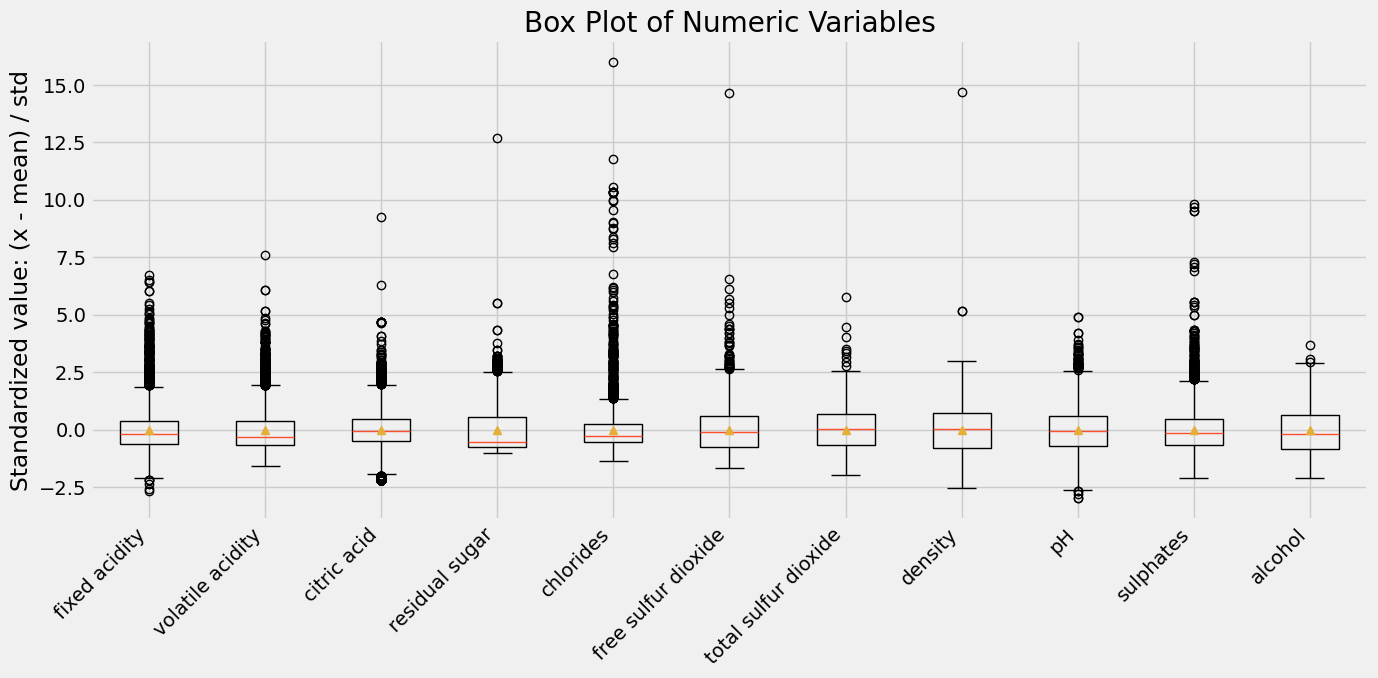

In [ ]:
#박스플롯을 이용한 시각화
plt.figure(figsize=(14, 7))
plt.boxplot(
    [scaled_for_plot[col].dropna().values for col in feature_cols],
    tick_labels=feature_cols,
    showmeans=True)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Standardized value: (x - mean) / std")

plt.title("Box Plot of Numeric Variables")

plt.tight_layout()

plt.show()

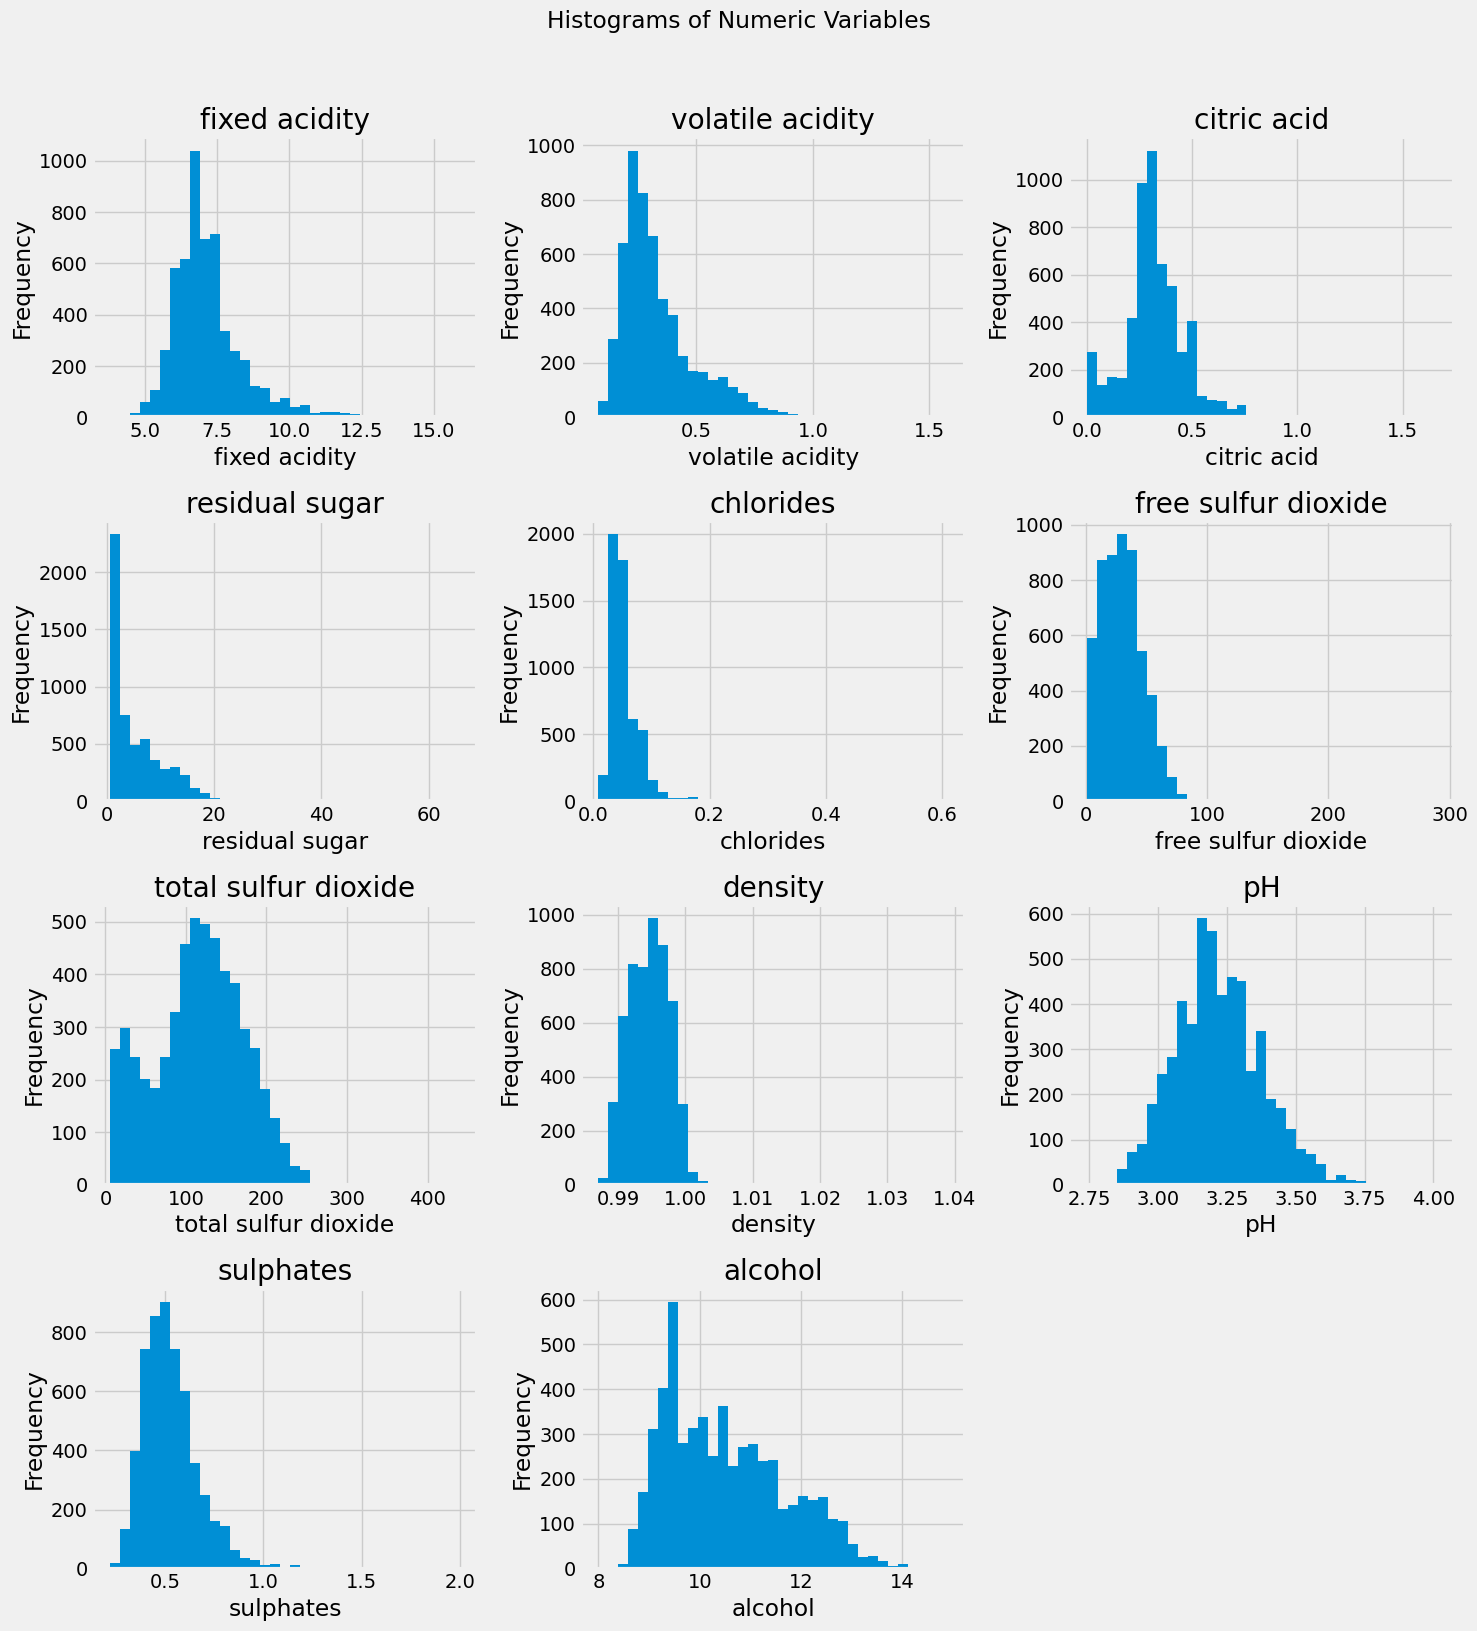

In [ ]:
#히스토그램을 이용한 데이터 분석 및 시각화
n_cols = 3

n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    ax.hist(train[col].dropna(), bins=35)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# 남는 빈 그래프 영역 제거

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.suptitle("Histograms of Numeric Variables", y=1.02)

plt.tight_layout()

plt.show()

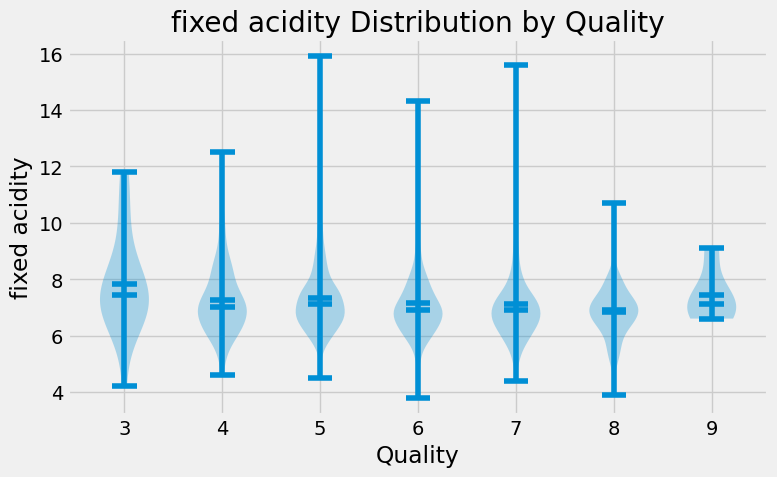

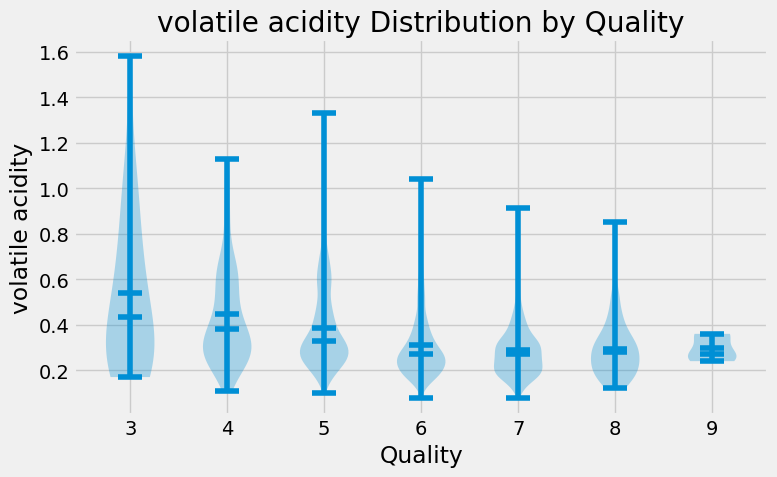

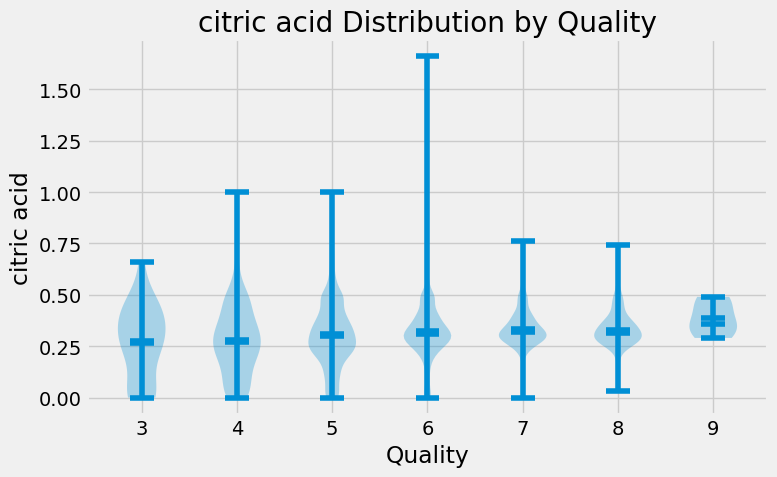

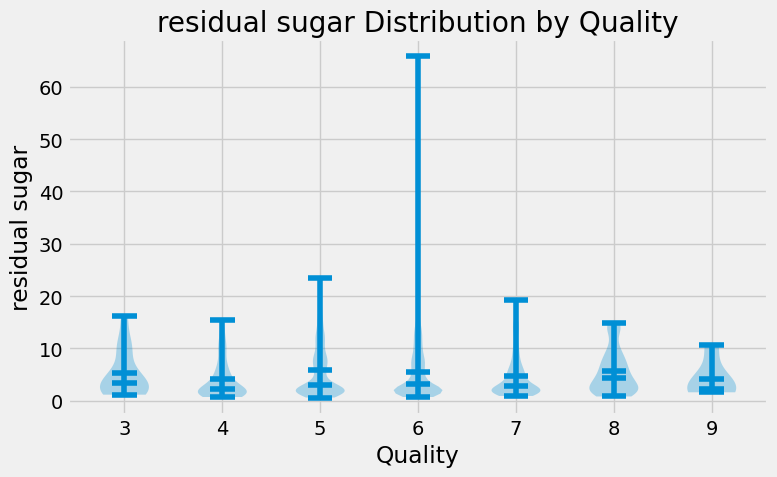

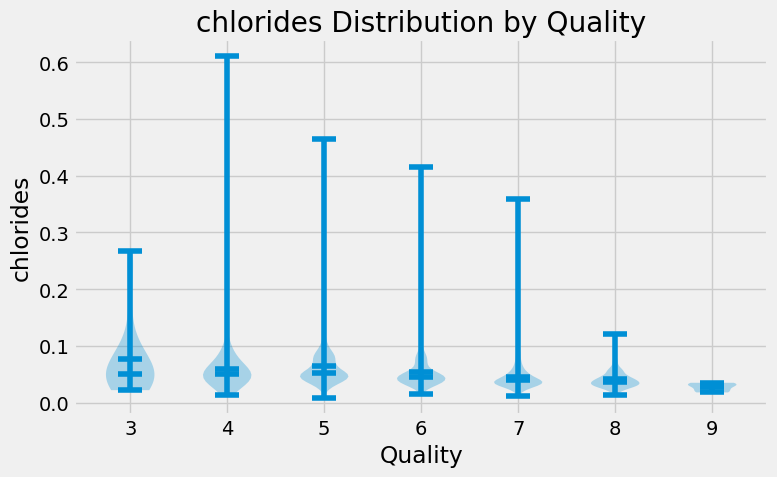

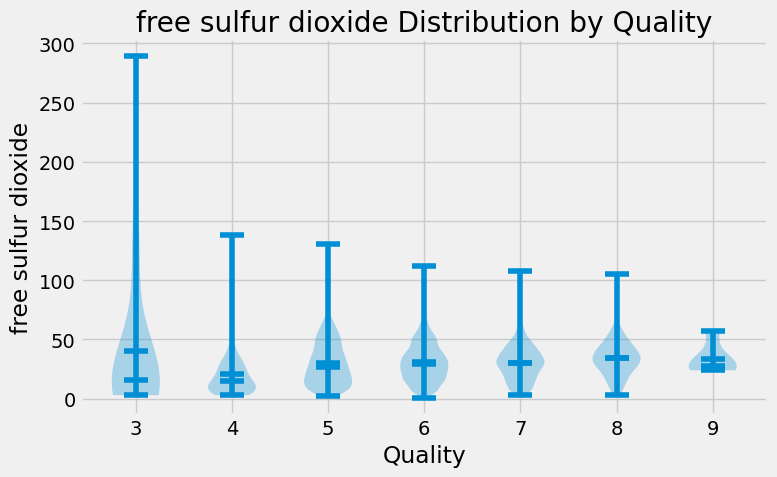

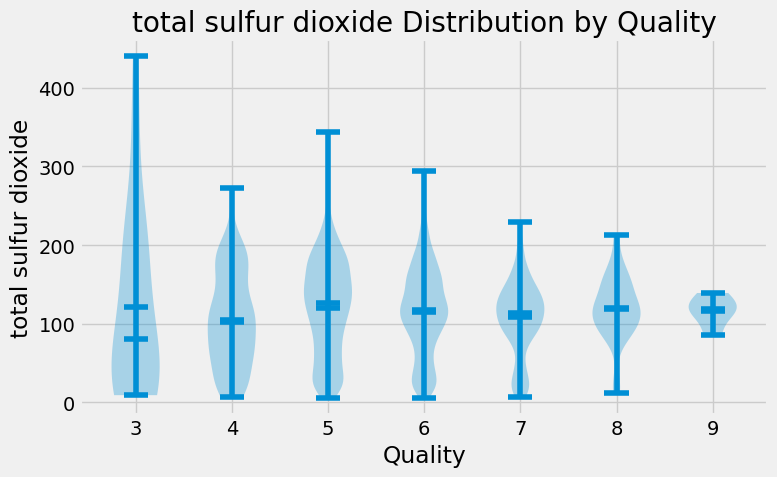

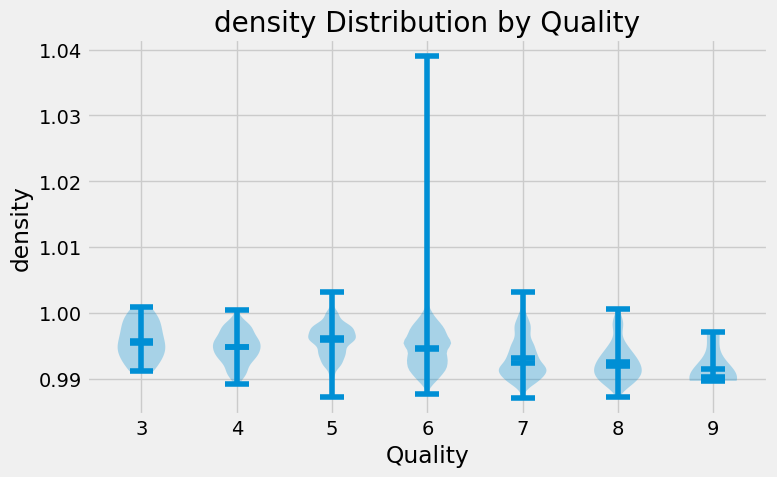

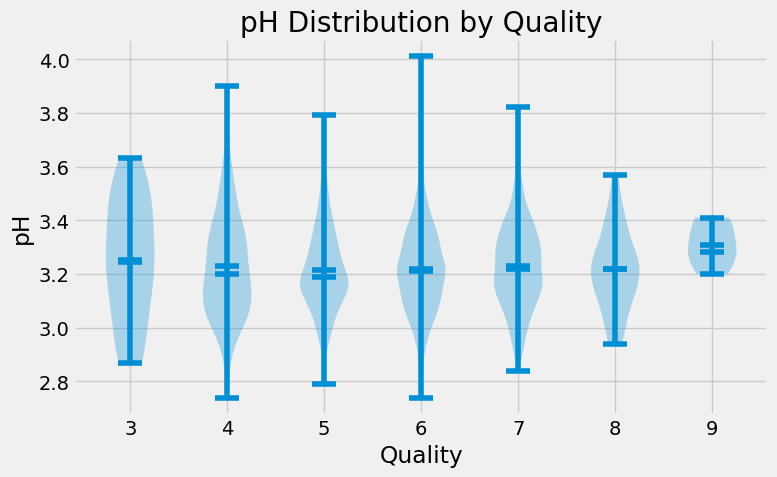

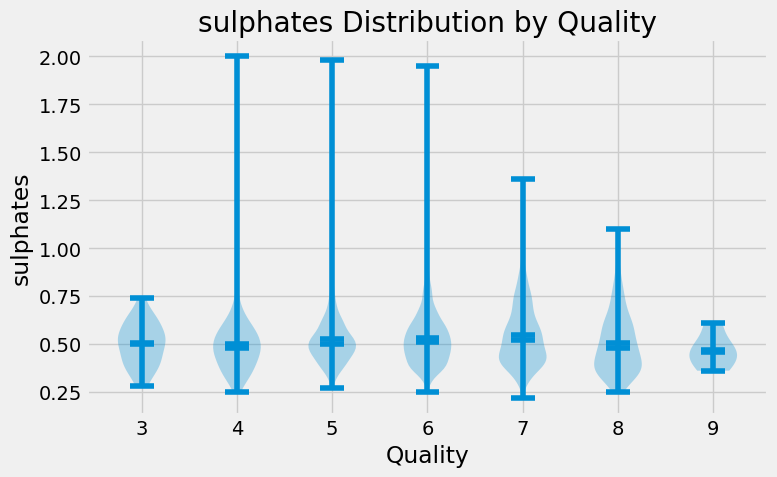

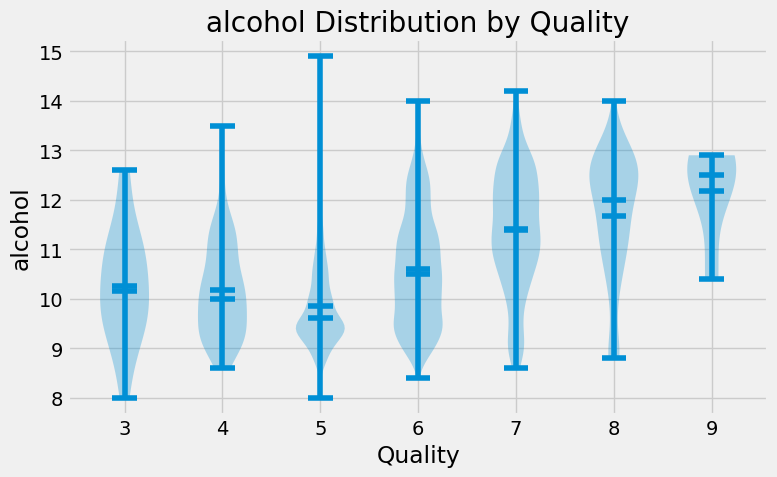

In [ ]:
#quality별 바이올린 플롯
quality_values = sorted(train["quality"].unique())
for col in feature_cols:
    data_by_quality = [
        train.loc[train["quality"] == q, col].dropna().values
        for q in quality_values]
    plt.figure(figsize=(8, 5))
    plt.violinplot(
        data_by_quality,
        showmeans=True,
        showmedians=True,
        showextrema=True)
    plt.xticks(ticks=range(1, len(quality_values) + 1),
        labels=quality_values)
    plt.xlabel("Quality")
    plt.ylabel(col)
    plt.title(f"{col} Distribution by Quality")
    plt.tight_layout()
    plt.show()

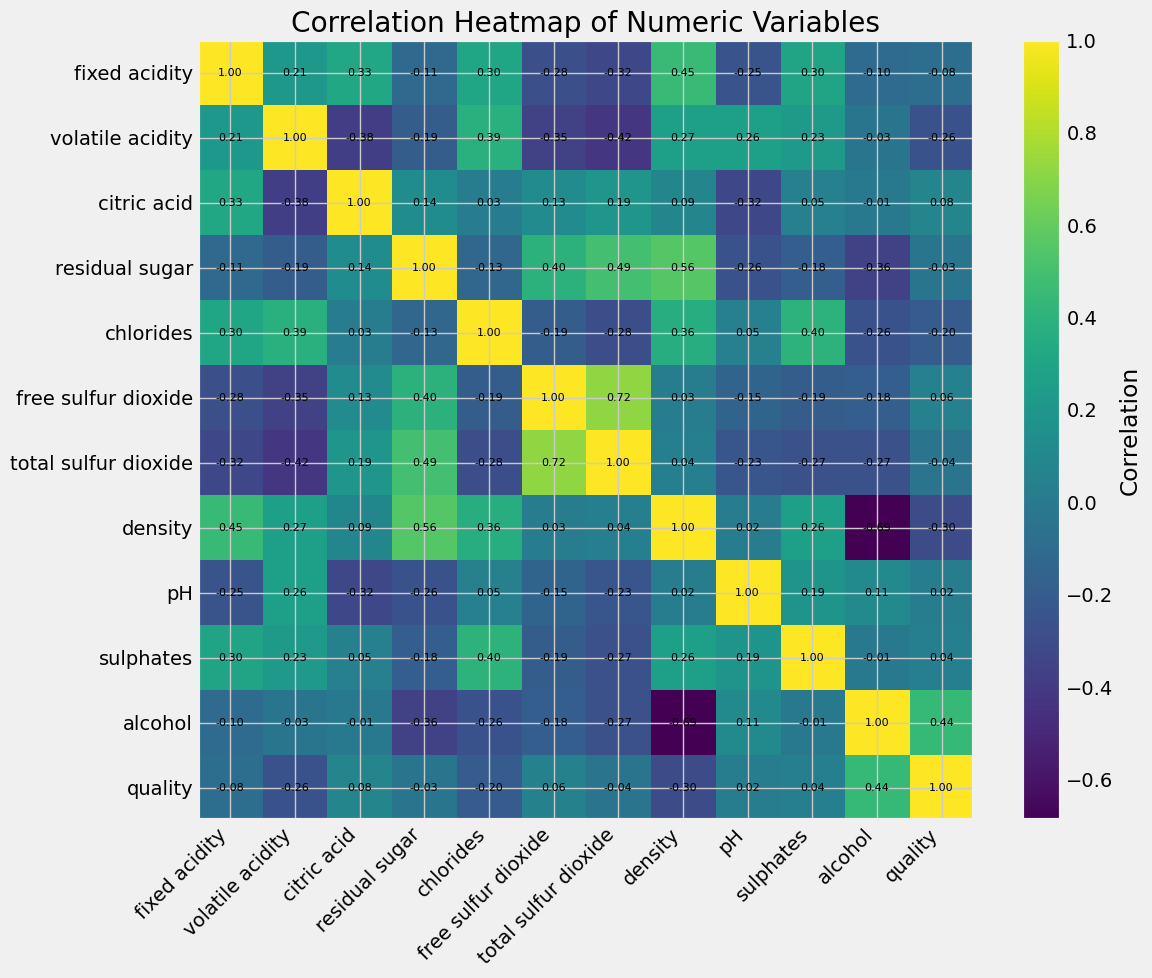

In [ ]:
#상관관계 히트맵
corr_cols = feature_cols + ["quality"]

corr = train[corr_cols].corr()

plt.figure(figsize=(12, 10))

plt.imshow(corr, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(corr.columns)),
    labels=corr.columns,
    rotation=45,
    ha="right")
plt.yticks(
    ticks=range(len(corr.index)),
    labels=corr.index)

plt.title("Correlation Heatmap of Numeric Variables")
# 상관계수 숫자 표시
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8)
plt.tight_layout()
plt.show()

##Standard Scaler를 통한 데이터 스케일링

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

test = test_data
print("train shape:", train.shape)
print("test shape:", test.shape)
print(train.head())

train shape: (5497, 14)
test shape: (1000, 13)
   index  quality  fixed acidity  volatile acidity  citric acid  \
0      0        5            5.6             0.695         0.06   
1      1        5            8.8             0.610         0.14   
2      2        5            7.9             0.210         0.39   
3      3        6            7.0             0.210         0.31   
4      4        6            7.8             0.400         0.26   

   residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0             6.8      0.042                  9.0                  84.0   
1             2.4      0.067                 10.0                  42.0   
2             2.0      0.057                 21.0                 138.0   
3             6.0      0.046                 29.0                 108.0   
4             9.5      0.059                 32.0                 178.0   

   density    pH  sulphates  alcohol   type  
0  0.99432  3.44       0.44     10.2  white  
1  0.99

In [ ]:
# 수치형 변수 전체 선택
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# index는 식별자, quality는 타깃 변수이므로 제외
exclude_cols = ["index", "quality"]
scale_cols = [col for col in numeric_cols if col not in exclude_cols]
print("StandardScaler 적용 대상 변수:")
print(scale_cols)
# 원본 데이터를 보존하기 위해 복사본 생성
train_scaled = train.copy()
test_scaled = test.copy()
# StandardScaler 객체 생성
scaler = StandardScaler()
# train 데이터 기준으로 평균과 표준편차 학습
scaler.fit(train[scale_cols])
# train, test 데이터에 동일한 기준 적용
train_scaled[scale_cols] = scaler.transform(train[scale_cols])
test_scaled[scale_cols] = scaler.transform(test[scale_cols])
print("스케일링 완료")

StandardScaler 적용 대상 변수:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
스케일링 완료


In [ ]:
print("스케일링 전 train 수치형 변수 요약")
display(train[scale_cols].describe().T)
print("스케일링 후 train 수치형 변수 요약")
display(train_scaled[scale_cols].describe().T)
check_scaling = pd.DataFrame({
    "mean_after_scaling": train_scaled[scale_cols].mean(),
    "std_after_scaling": train_scaled[scale_cols].std()
})
check_scaling

스케일링 전 train 수치형 변수 요약


,count,mean,std,min,25%,50%,75%,max
fixed acidity,5497.0,7.210115,1.287579,3.80000,6.4000,7.0000,7.70000,15.90000
volatile acidity,5497.0,0.338163,0.163224,0.08000,0.2300,0.2900,0.40000,1.58000
citric acid,5497.0,0.318543,0.145104,0.00000,0.2500,0.3100,0.39000,1.66000
residual sugar,5497.0,5.438075,4.756676,0.60000,1.8000,3.0000,8.10000,65.80000
chlorides,5497.0,0.055808,0.034653,0.00900,0.0380,0.0470,0.06400,0.61000
free sulfur dioxide,5497.0,30.417682,17.673881,1.00000,17.0000,29.0000,41.00000,289.00000
total sulfur dioxide,5497.0,115.566491,56.288223,6.00000,78.0000,118.0000,155.00000,440.00000
density,5497.0,0.994673,0.003014,0.98711,0.9923,0.9948,0.99693,1.03898
pH,5497.0,3.219502,0.160713,2.74000,3.1100,3.2100,3.32000,4.01000
sulphates,5497.0,0.530524,0.149396,0.22000,0.4300,0.5100,0.60000,2.00000


스케일링 후 train 수치형 변수 요약


,count,mean,std,min,25%,50%,75%,max
fixed acidity,5497.0,-4.524103e-18,1.000091,-2.648711,-0.629234,-0.163201,0.380505,6.749625
volatile acidity,5497.0,-1.900123e-16,1.000091,-1.581787,-0.662723,-0.295097,0.378883,7.608856
citric acid,5497.0,-5.816704e-17,1.000091,-2.195474,-0.472414,-0.058879,0.492500,9.245647
residual sugar,5497.0,-1.809641e-17,1.000091,-1.017205,-0.764905,-0.512605,0.559670,12.691092
chlorides,5497.0,1.454176e-17,1.000091,-1.350876,-0.513939,-0.254200,0.236418,15.993924
free sulfur dioxide,5497.0,-7.884866e-17,1.000091,-1.664624,-0.759250,-0.080221,0.598809,14.632091
total sulfur dioxide,5497.0,8.014126e-17,1.000091,-1.946703,-0.667456,0.043237,0.700628,5.764315
density,5497.0,1.981105e-14,1.000091,-2.509732,-0.787545,0.042025,0.748819,14.702182
pH,5497.0,2.274978e-15,1.000091,-2.983864,-0.681411,-0.059127,0.625386,4.919150
sulphates,5497.0,3.877803e-18,1.000091,-2.078720,-0.672931,-0.137392,0.465089,9.837018


,mean_after_scaling,std_after_scaling
fixed acidity,-4.524103e-18,1.000091
volatile acidity,-1.900123e-16,1.000091
citric acid,-5.816704e-17,1.000091
residual sugar,-1.809641e-17,1.000091
chlorides,1.454176e-17,1.000091
free sulfur dioxide,-7.884866e-17,1.000091
total sulfur dioxide,8.014126e-17,1.000091
density,1.981105e-14,1.000091
pH,2.274978e-15,1.000091
sulphates,3.877803e-18,1.000091


In [ ]:
check_scaling_exact = pd.DataFrame({
    "mean_after_scaling": train_scaled[scale_cols].mean(),
    "std_after_scaling_ddof0": train_scaled[scale_cols].std(ddof=0)
})
check_scaling_exact

,mean_after_scaling,std_after_scaling_ddof0
fixed acidity,-4.524103e-18,1.0
volatile acidity,-1.900123e-16,1.0
citric acid,-5.816704e-17,1.0
residual sugar,-1.809641e-17,1.0
chlorides,1.454176e-17,1.0
free sulfur dioxide,-7.884866e-17,1.0
total sulfur dioxide,8.014126e-17,1.0
density,1.981105e-14,1.0
pH,2.274978e-15,1.0
sulphates,3.877803e-18,1.0


In [ ]:
#스케일링한 내용 저장
train_scaled.to_csv("train_standard_scaled.csv", index=False, encoding="utf-8-sig")
test_scaled.to_csv("test_standard_scaled.csv", index=False, encoding="utf-8-sig")
print("저장 완료:")
print("train_standard_scaled.csv")
print("test_standard_scaled.csv")

저장 완료:
train_standard_scaled.csv
test_standard_scaled.csv


##MinMaxScaler를 이용하여 분석하기

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("train shape:", train.shape)
print("test shape:", test.shape)

# 수치형 변수 전체 선택
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# 제외할 변수
# index: 식별자
# quality: 타깃 변수
exclude_cols = ["index", "quality"]
scale_cols = [col for col in numeric_cols if col not in exclude_cols]
print("MinMaxScaler 적용 대상 변수:")
print(scale_cols)

# 원본 보존을 위해 복사본 생성
train_minmax_scaled = train.copy()
test_minmax_scaled = test.copy()

# MinMaxScaler 객체 생성
scaler = MinMaxScaler()

# train 데이터 기준으로 최솟값과 최댓값 학습
train_minmax_scaled[scale_cols] = scaler.fit_transform(train[scale_cols])

# test 데이터는 train 기준으로 변환
test_minmax_scaled[scale_cols] = scaler.transform(test[scale_cols])

print("스케일링 전 train 요약")
display(train[scale_cols].describe().T)

print("MinMaxScaler 적용 후 train 요약")
display(train_minmax_scaled[scale_cols].describe().T)

train shape: (5497, 14)
test shape: (1000, 13)
MinMaxScaler 적용 대상 변수:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
스케일링 전 train 요약


,count,mean,std,min,25%,50%,75%,max
fixed acidity,5497.0,7.210115,1.287579,3.80000,6.4000,7.0000,7.70000,15.90000
volatile acidity,5497.0,0.338163,0.163224,0.08000,0.2300,0.2900,0.40000,1.58000
citric acid,5497.0,0.318543,0.145104,0.00000,0.2500,0.3100,0.39000,1.66000
residual sugar,5497.0,5.438075,4.756676,0.60000,1.8000,3.0000,8.10000,65.80000
chlorides,5497.0,0.055808,0.034653,0.00900,0.0380,0.0470,0.06400,0.61000
free sulfur dioxide,5497.0,30.417682,17.673881,1.00000,17.0000,29.0000,41.00000,289.00000
total sulfur dioxide,5497.0,115.566491,56.288223,6.00000,78.0000,118.0000,155.00000,440.00000
density,5497.0,0.994673,0.003014,0.98711,0.9923,0.9948,0.99693,1.03898
pH,5497.0,3.219502,0.160713,2.74000,3.1100,3.2100,3.32000,4.01000
sulphates,5497.0,0.530524,0.149396,0.22000,0.4300,0.5100,0.60000,2.00000


MinMaxScaler 적용 후 train 요약


,count,mean,std,min,25%,50%,75%,max
fixed acidity,5497.0,0.281828,0.106411,0.0,0.214876,0.264463,0.322314,1.0
volatile acidity,5497.0,0.172108,0.108816,0.0,0.100000,0.140000,0.213333,1.0
citric acid,5497.0,0.191893,0.087412,0.0,0.150602,0.186747,0.234940,1.0
residual sugar,5497.0,0.074204,0.072955,0.0,0.018405,0.036810,0.115031,1.0
chlorides,5497.0,0.077884,0.057659,0.0,0.048253,0.063228,0.091514,1.0
free sulfur dioxide,5497.0,0.102145,0.061368,0.0,0.055556,0.097222,0.138889,1.0
total sulfur dioxide,5497.0,0.252457,0.129696,0.0,0.165899,0.258065,0.343318,1.0
density,5497.0,0.145814,0.058105,0.0,0.100058,0.148255,0.189319,1.0
pH,5497.0,0.377560,0.126546,0.0,0.291339,0.370079,0.456693,1.0
sulphates,5497.0,0.174452,0.083930,0.0,0.117978,0.162921,0.213483,1.0


In [ ]:
check_minmax = pd.DataFrame({
    "min_after_scaling": train_minmax_scaled[scale_cols].min(),
    "max_after_scaling": train_minmax_scaled[scale_cols].max()
})
check_minmax

,min_after_scaling,max_after_scaling
fixed acidity,0.0,1.0
volatile acidity,0.0,1.0
citric acid,0.0,1.0
residual sugar,0.0,1.0
chlorides,0.0,1.0
free sulfur dioxide,0.0,1.0
total sulfur dioxide,0.0,1.0
density,0.0,1.0
pH,0.0,1.0
sulphates,0.0,1.0


## 이상치 파악하기

In [ ]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# index는 식별자, quality는 타깃 변수이므로 제외
exclude_cols = ["index", "quality"]
box_cols = [col for col in numeric_cols if col not in exclude_cols]
print("박스플롯 대상 변수:")
print(box_cols)

박스플롯 대상 변수:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
outlier_summary = []
for col in box_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = (
        (train[col] < lower_bound) |
        (train[col] > upper_bound)
    ).sum()
    outlier_rate = outlier_count / len(train)
    outlier_summary.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_rate": outlier_rate
    })
outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary = outlier_summary.sort_values(
    "outlier_rate",
    ascending=False
)
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
2,citric acid,0.2500,0.39000,0.14000,0.040000,0.600000,430,0.078224
1,volatile acidity,0.2300,0.40000,0.17000,-0.025000,0.655000,314,0.057122
0,fixed acidity,6.4000,7.70000,1.30000,4.450000,9.650000,294,0.053484
4,chlorides,0.0380,0.06400,0.02600,-0.001000,0.103000,259,0.047117
9,sulphates,0.4300,0.60000,0.17000,0.175000,0.855000,161,0.029289
3,residual sugar,1.8000,8.10000,6.30000,-7.650000,17.550000,106,0.019283
8,pH,3.1100,3.32000,0.21000,2.795000,3.635000,60,0.010915
5,free sulfur dioxide,17.0000,41.00000,24.00000,-19.000000,77.000000,47,0.008550
6,total sulfur dioxide,78.0000,155.00000,77.00000,-37.500000,270.500000,9,0.001637
7,density,0.9923,0.99693,0.00463,0.985355,1.003875,3,0.000546


박스플롯 대상 변수:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


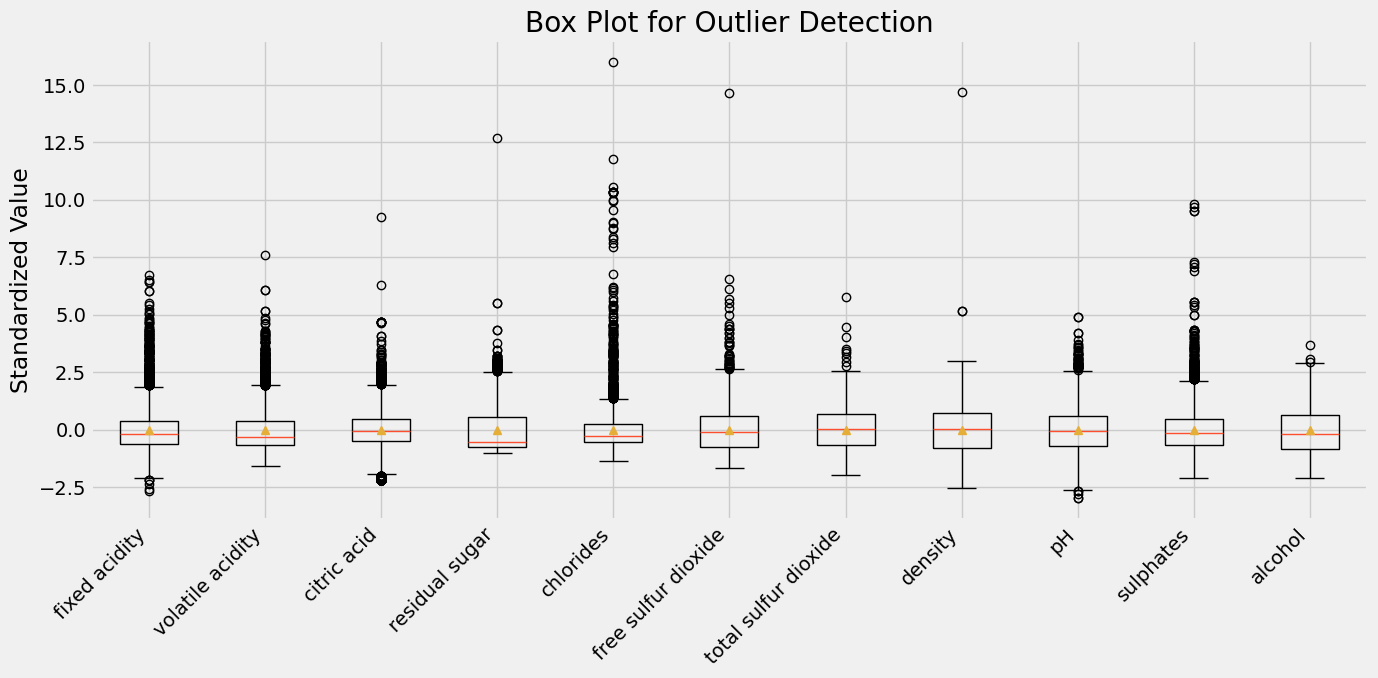

In [ ]:
#박스 플롯을 이용한 이상치 나타내기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
train.head

# 2. 수치형 변수 선택
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# 3. index와 quality는 제외
# index: 식별자
# quality: 타깃 변수
exclude_cols = ["index", "quality"]
box_cols = [col for col in numeric_cols if col not in exclude_cols]
print("박스플롯 대상 변수:")
print(box_cols)

# 4. 변수별 단위 차이를 맞추기 위해 표준화
scaled_data = (
    train[box_cols] - train[box_cols].mean()
) / train[box_cols].std(ddof=0)

# 5. 박스플롯 그리기
plt.figure(figsize=(14, 7))
plt.boxplot(
    [scaled_data[col].dropna() for col in box_cols],
    tick_labels=box_cols,
    showmeans=True
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standardized Value")
plt.title("Box Plot for Outlier Detection")
plt.tight_layout()
plt.show()

# 데이터 불균형 확인

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
    )

from imblearn.over_sampling import SMOTE

plt.style.use('fivethirtyeight')

In [ ]:
#quality 분포 확인
quality_counts=train["quality"].value_counts().sort_index()

print("quality 클래스별 데이터 개수")
display(quality_counts)

quality 클래스별 데이터 개수


,count
quality,
3,26
4,186
5,1788
6,2416
7,924
8,152
9,5


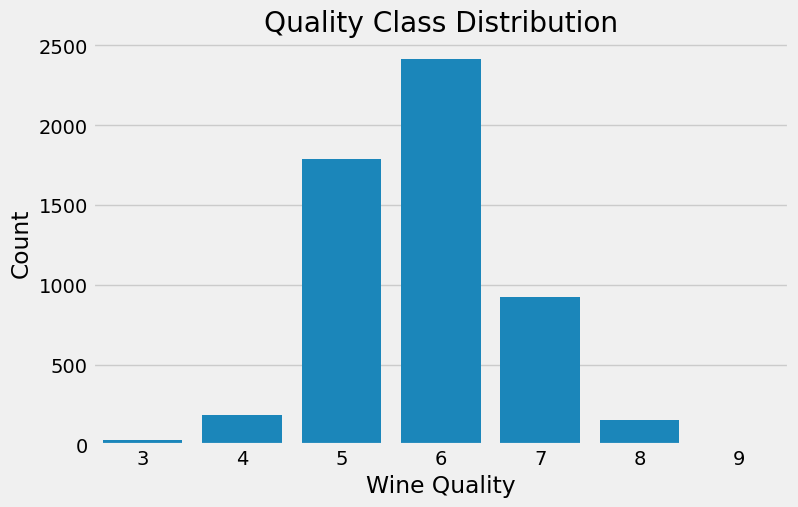

In [ ]:
# quality 분포 그래프로 확인

plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="quality",
    order=sorted(train["quality"].unique())
)

plt.title("Quality Class Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()

In [ ]:
# 모델링용 데이터 분리
# 입력(x), 정답(y) 나누기

x=train.drop(["index","quality"], axis=1)
y=train["quality"]

test_X=test.drop("index", axis=1)

print("X shape:", x.shape)
print("y shape:", y.shape)
print("test_X shape:", test_X.shape)

display(x.head())

X shape: (5497, 12)
y shape: (5497,)
test_X shape: (1000, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


In [ ]:
# 번주형 변수 인코딩
# type은 문자라 모델이 못읽음
X=pd.get_dummies(x, columns=["type"], drop_first=True)
test_X=pd.get_dummies(test_X, columns=["type"], drop_first=True)

# train과 test 컬럼 순서 맞추기
test_=test_X.reindex(columns=X.columns, fill_value=0)

print("인코딩 후 X shape:", X.shape)
print("인코딩 후 test_X shape:", test_X.shape)

display(X.head())

인코딩 후 X shape: (5497, 12)
인코딩 후 test_X shape: (1000, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
0,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,True
1,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,False
2,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,True
3,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,True
4,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,True


# 새로운 변수 추가

In [ ]:
# 1. 총 산도 (Total Acidity)
X['total_acidity'] = X['fixed acidity'] + X['volatile acidity']
test_X['total_acidity'] = test_X['fixed acidity'] + test_X['volatile acidity']

# 2. 결합 이산화황 (Bound Sulfur Dioxide)
X['bound_sulfur_dioxide'] = X['total sulfur dioxide'] - X['free sulfur dioxide']
test_X['bound_sulfur_dioxide'] = test_X['total sulfur dioxide'] - test_X['free sulfur dioxide']

# 3. 활성 이산화황 (Free Ratio)
X['free_ratio'] = X['free sulfur dioxide'] / X['total sulfur dioxide']
test_X['free_ratio'] = test_X['free sulfur dioxide'] / test_X['total sulfur dioxide']

# 4. 알코올 대비 당도 (Sugar to Alcohol Ratio)
# 주의: 알코올이 0일 경우 에러가 나지 않도록 아주 작은 값인 1e-6을 더해줌
X['sugar_to_alcohol'] = X['residual sugar'] / (X['alcohol'] + 1e-6)
test_X['sugar_to_alcohol'] = test_X['residual sugar'] / (test_X['alcohol'] + 1e-6)

X['total_acidity'].head()
X['bound_sulfur_dioxide'].head()
X['sugar_to_alcohol'].head()

,sugar_to_alcohol
0,0.666667
1,0.252632
2,0.183486
3,0.555556
4,0.871560


# 데이터셋 분할 (Train/Validation Split)

In [ ]:
# 데이터를 학습용(train), 검증용(validation)으로 나눔

X_train, X_val, y_train, y_val=train_test_split(
    X,
    y,
    test_size=0.2,  #20%는 검증용
    random_state=42,
    stratify=y     #stratify=y를 통해 quality 비율 유지하면서 분할
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (4397, 16)
X_val shape: (1100, 16)
y_train shape: (4397,)
y_val shape: (1100,)


In [ ]:
# 분할 후 quality 분포 확인

print("Train quality distribution")
display(y_train.value_counts().sort_index())

print("Validation quality distribution")
display(y_val.value_counts().sort_index())

Train quality distribution


,count
quality,
3,21
4,149
5,1430
6,1932
7,739
8,122
9,4


Validation quality distribution


,count
quality,
3,5
4,37
5,358
6,484
7,185
8,30
9,1


In [ ]:
# StandardScaler
# 숫자 크기 단위 맞추는 작업
# 단위가 너무 다르면 모델이 큰 숫자 변수를 더 중요하게 볼 수 있음.
# 평균 0, 표준편차 1 정도로 맞춰주기

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)   #train 기준으로 평균/표준편차 계산,변환
X_val_scaled=scaler.transform(X_val)
test_X_scaled=scaler.transform(test_X)

# SMOTE를 활용한 데이터 불균형 해소 (오버샘플링)

In [ ]:
#SMOTE를 통해, 부족한 클래스의 데이터를 인위적으로 늘려줌

smote=SMOTE(random_state=42, k_neighbors=3)

# 검증 데이터에 SMOTE를 하면 성능 평가가 부정확해짐.
# SMOTE는 학습 데이터에만 적용.
X_train_smote, y_train_smote=smote.fit_resample(
    X_train_scaled,
    y_train
)


# 로지스틱 회귀 모델 학습


In [ ]:
log_model=LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression 모델 학습 완료")

Logistic Regression 모델 학습 완료


In [ ]:
# Validation 데이터 품질 예측

val_pred=log_model.predict(X_val_scaled)

print("예측값 일부 확인")
print(val_pred[:20])

예측값 일부 확인
[5 3 6 8 5 7 7 7 3 6 4 5 3 7 7 5 8 4 3 8]


# 기본적인 평가지표 도출

In [ ]:
accuracy=accuracy_score(y_val, val_pred)
precision_macro=precision_score(y_val, val_pred, average="macro", zero_division=0)
recall_macro=recall_score(y_val, val_pred, average="macro", zero_division=0)
f1_macro=f1_score(y_val, val_pred, average="macro", zero_division=0)

precision_weighted=precision_score(y_val, val_pred, average="weighted", zero_division=0)
recall_weighted=recall_score(y_val, val_pred, average="weighted", zero_division=0)
f1_weighted=f1_score(y_val, val_pred, average="weighted", zero_division=0)

eval_result=pd.DataFrame({
    "Model": ["Logistic Regression + SMOTE"],
    "Accuracy":[accuracy],
    "Precision macro":[precision_macro],
    "Recall_macro":[precision_macro],
    "F1_macro":[f1_macro],
    "Precision_weighted":[precision_weighted],
    "Recall_weighted":[recall_weighted],
    "F1_weighted":[f1_weighted]
})

display(eval_result)

,Model,Accuracy,Precision macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,Logistic Regression + SMOTE,0.33,0.247429,0.247429,0.226216,0.503694,0.33,0.378697


In [ ]:
# Classification Report
# 각 quality 클래스별 성능을 자세히 보기 위해서
# 특정 점수만 잘 맞히는 모델인지, 전체 품질 점수를 골고루 맞히는 모델인지 등 확인

print(classification_report(y_val, val_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.02      0.40      0.03         5
           4       0.11      0.43      0.18        37
           5       0.62      0.44      0.51       358
           6       0.56      0.25      0.35       484
           7       0.30      0.28      0.29       185
           8       0.07      0.43      0.13        30
           9       0.05      1.00      0.10         1

    accuracy                           0.33      1100
   macro avg       0.25      0.46      0.23      1100
weighted avg       0.50      0.33      0.38      1100



In [ ]:
# Confusion Matrix
# 모델이 어떤 것을 헷갈렸는지 확인 가능

labels=sorted(y.unique())

cm=confusion_matrix(y_val, val_pred, labels=labels)

cm_df=pd.DataFrame(
    cm,
    index=[f"True {label}" for label in labels],
    columns=[f"Pred {label}" for label in labels]
)

display(cm_df)

,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
True 3,2,1,0,0,0,1,1
True 4,8,16,6,5,2,0,0
True 5,49,57,156,48,20,27,1
True 6,48,59,77,123,91,78,8
True 7,7,9,13,39,52,57,8
True 8,2,2,1,5,6,13,1
True 9,0,0,0,0,0,0,1


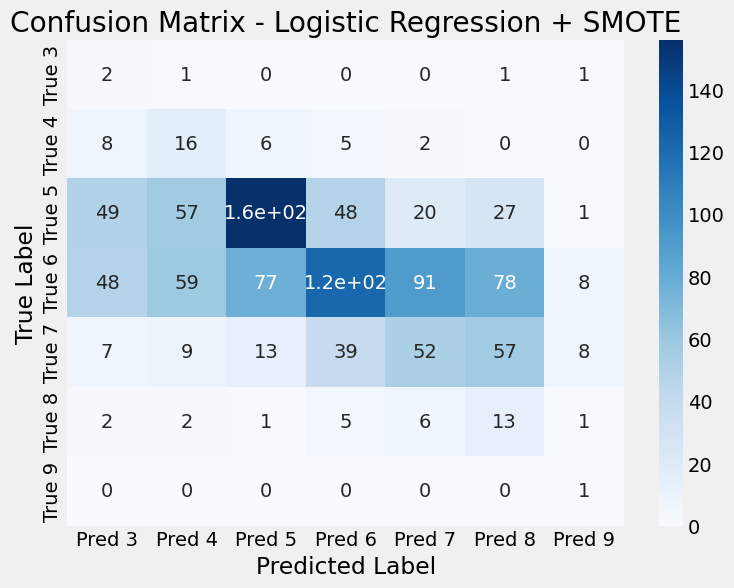

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_df,
    annot=True,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression + SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# 최종 test 데이터 예측

test_pred=log_model.predict(test_X_scaled)

print("test 예측값 일부")
print(test_pred[:20])

test 예측값 일부
[3 3 5 4 7 3 6 7 6 8 5 5 3 6 6 5 6 8 3 5]


# 랜덤 포레스트, XGBoost, LightGBM 모델 학습

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# XGBoost와 LightGBM을 위해 타깃 변수(3~9)를 0~6으로 변환
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

print("원래 품질 점수 클래스:", le.classes_)
print("인코딩된 모델용 클래스:", np.unique(y_train_encoded))

원래 품질 점수 클래스: [3 4 5 6 7 8 9]
인코딩된 모델용 클래스: [0 1 2 3 4 5 6]


In [ ]:
# 모델 객체 생성
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, random_state=42)
lgbm_model = LGBMClassifier(n_estimators=300, learning_rate=0.1, class_weight='balanced', random_state=42)

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

# 빈 리스트 준비
acc_list = []
f1_list = []
precision_list = []
recall_list = []

model_names = ['Random Forest', 'XGBoost', 'LightGBM']
models = [rf_model, xgb_model, lgbm_model]

for i, model in enumerate(models):
    model.fit(X_train_scaled, y_train_encoded)

    val_pred_encoded = model.predict(X_val_scaled)

    acc = accuracy_score(y_val_encoded, val_pred_encoded)
    f1_macro = f1_score(y_val_encoded, val_pred_encoded, average='macro')
    precision_macro = precision_score(y_val_encoded, val_pred_encoded, average='macro')
    recall_macro = recall_score(y_val_encoded, val_pred_encoded, average='macro')

    acc_list.append(acc)
    f1_list.append(f1_macro)
    precision_list.append(precision_macro)
    recall_list.append(recall_macro)

    print(f"{model_names[i]} 학습 및 검증 평가 완료")


eval_df = pd.DataFrame({
    'Accuracy': acc_list,
    'Precision (Macro)': precision_list,
    'Recall (Macro)': recall_list,
    'F1 Score (Macro)': f1_list
}, index=model_names)

display(eval_df)

Random Forest 학습 및 검증 평가 완료
XGBoost 학습 및 검증 평가 완료
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2467
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 16
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Random Forest,0.644545,0.466559,0.344406,0.374431
XGBoost,0.640909,0.415250,0.358664,0.377829
LightGBM,0.626364,0.414952,0.359695,0.379034


# 모델별 성능 비교 및 Confusion Matrix

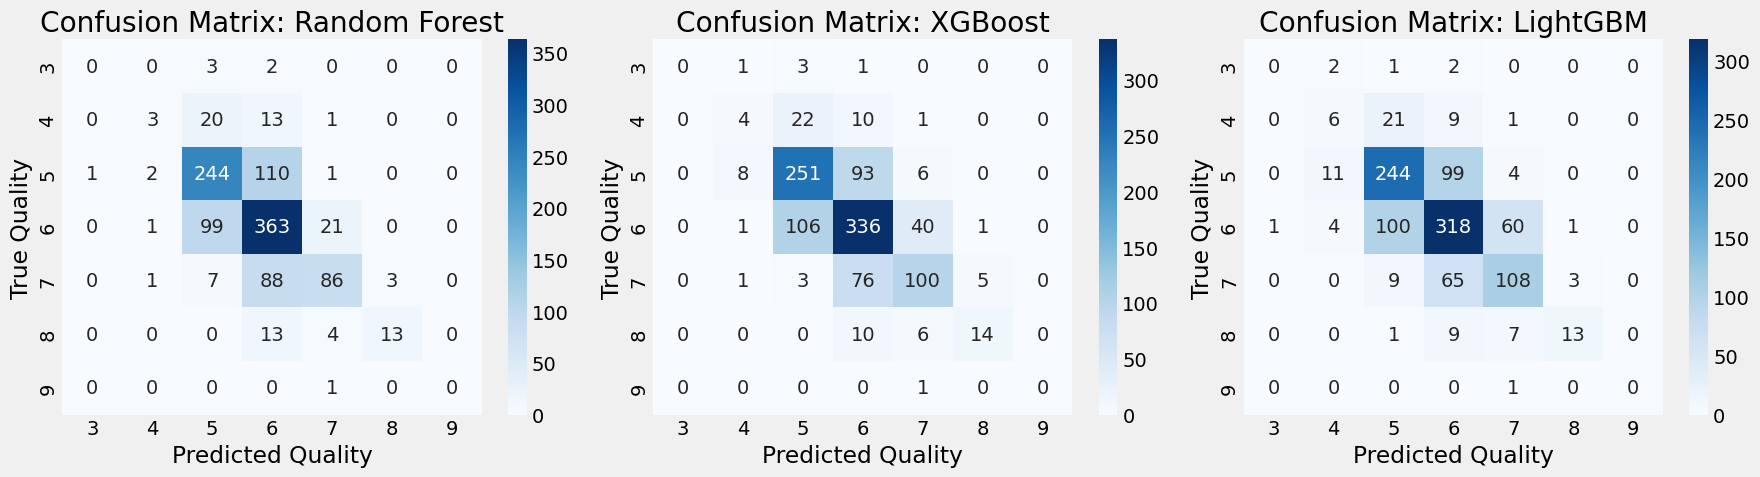

In [ ]:
f, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, model in enumerate(models):
    val_pred_encoded = model.predict(X_val_scaled)

    cm = confusion_matrix(y_val_encoded, val_pred_encoded)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[i],
                xticklabels=le.classes_, yticklabels=le.classes_)

    ax[i].set_title(f'Confusion Matrix: {model_names[i]}')
    ax[i].set_ylabel('True Quality')
    ax[i].set_xlabel('Predicted Quality')

plt.tight_layout()
plt.show()

# 특성 중요도(Feature Importance) 확인

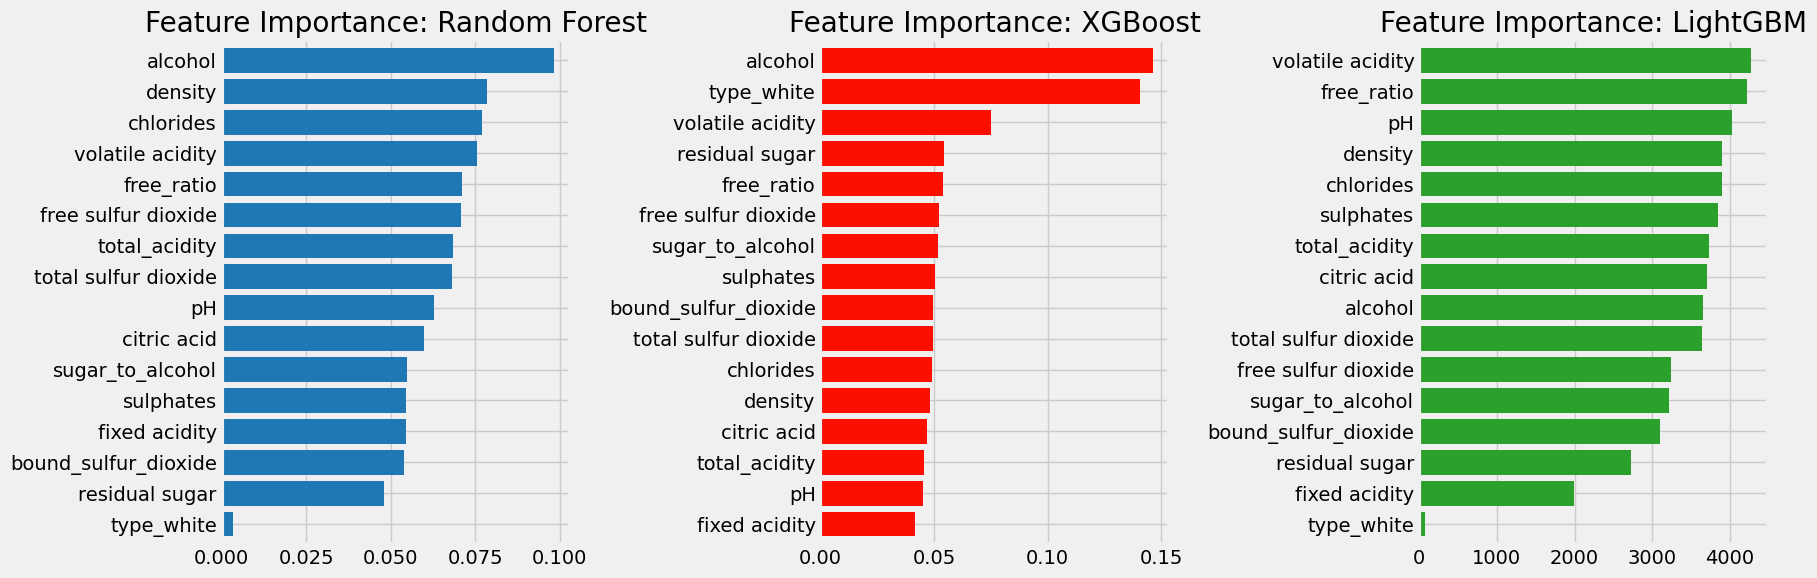

In [ ]:
f, ax = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#1f77b4', '#FD0F00', '#2ca02c'] # 각각 파란색, 빨간색, 초록색

for i, model in enumerate(models):
    # 각 모델의 특성 중요도 추출
    importances = model.feature_importances_

    # Series로 변환 후 크기순으로 정렬
    feat_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

    feat_importances.plot.barh(width=0.8, ax=ax[i], color=colors[i])
    ax[i].set_title(f'Feature Importance: {model_names[i]}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. 기존에 나눈 train, val 데이터를 다시 합치기
X_full_scaled = np.vstack((X_train_scaled, X_val_scaled))
y_full_encoded = np.concatenate((y_train_encoded, y_val_encoded))

# 2. 개별 모델 3개 정의
rf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
lgbm_clf = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)

# 3. Soft Voting 앙상블 모델 생성 (3개 모델의 예측 확률을 평균 계산)
voting_clf = VotingClassifier(
    estimators=[('RF', rf_clf), ('XGB', xgb_clf), ('LGBM', lgbm_clf)],
    voting='soft'
)

# 4. Stratified K-Fold 교차 검증 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_pred_proba = np.zeros((test_X_scaled.shape[0], len(np.unique(y_full_encoded))))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full_scaled, y_full_encoded)):
    X_tr, y_tr = X_full_scaled[train_idx], y_full_encoded[train_idx]

    voting_clf.fit(X_tr, y_tr)

    test_pred_proba += voting_clf.predict_proba(test_X_scaled) / skf.n_splits

test_pred_encoded = np.argmax(test_pred_proba, axis=1)

# 5. 인코딩된 예측값(0~6)을 다시 원래 와인 품질 점수(3~9)로 복구
test_pred_original = le.inverse_transform(test_pred_encoded)

# 6. 제출 파일 덮어쓰기 및 저장
submission_data['quality'] = test_pred_original
submission_filename = 'wine_quality_submission__YB_team2.csv'
submission_data.to_csv(submission_filename, index=False)

submission_data.head()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2475
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 16
[LightGBM] [Info] Start training from score -5.344155
[LightGBM] [Info] Start training from score -3.384731
[LightGBM] [Info] Start training from score -1.123248
[LightGBM] [Info] Start training from score -0.821849
[LightGBM] [Info] Start training from score -1.783380
[LightGBM] [Info] Start training from score -3.592887
[LightGBM] [Info] Start training from score -7.002383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

,index,quality
0,0,5
1,1,6
2,2,6
3,3,5
4,4,6
